# Telco Customer Churn Analysis
**Objective:** Identify key drivers of customer churn and quantify revenue risk.  
**Dataset:** IBM Telco Customer Churn — 7,043 customers, 21 features  
**Analyst:** Sabari AS

In [35]:
# ── Imports ──────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
import os

warnings.filterwarnings("ignore")

# ── Style ────────────────────────────────────────────────
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({
    "figure.dpi"        : 150,
    "figure.facecolor"  : "white",
    "axes.facecolor"    : "#FAFAFA",
    "axes.spines.top"   : False,
    "axes.spines.right" : False,
})

# ── Colors ───────────────────────────────────────────────
CHURN_COLOR   = "#E24B4A"
RETAIN_COLOR  = "#1D9E75"
NEUTRAL_COLOR = "#378ADD"
AMBER_COLOR   = "#FAC775"

# ── Paths ────────────────────────────────────────────────
BASE_DIR  = r"E:\Customer churn"
DATA_PATH = os.path.join(BASE_DIR, "customer churn.csv")
VIZ_DIR   = os.path.join(BASE_DIR, "visuals")
os.makedirs(VIZ_DIR, exist_ok=True)

print("✅ Libraries loaded successfully")
print(f"✅ Visuals will be saved to: {VIZ_DIR}")

✅ Libraries loaded successfully
✅ Visuals will be saved to: E:\Customer churn\visuals


In [36]:
# ── Imports ──────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
import os

warnings.filterwarnings("ignore")

# ── Style ────────────────────────────────────────────────
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({
    "figure.dpi"        : 150,
    "figure.facecolor"  : "white",
    "axes.facecolor"    : "#FAFAFA",
    "axes.spines.top"   : False,
    "axes.spines.right" : False,
})

# ── Colors ───────────────────────────────────────────────
CHURN_COLOR   = "#E24B4A"
RETAIN_COLOR  = "#1D9E75"
NEUTRAL_COLOR = "#378ADD"
AMBER_COLOR   = "#FAC775"
# ── Paths ────────────────────────────────────────────────
BASE_DIR  = r"E:\Customer churn"
DATA_PATH = r"E:\Customer churn\Data\customer churn.csv"
VIZ_DIR   = os.path.join(BASE_DIR, "visuals")
os.makedirs(VIZ_DIR, exist_ok=True)

print("✅ Libraries loaded successfully")
print(f"✅ Data path: {DATA_PATH}")
print(f"✅ Visuals folder ready: {VIZ_DIR}")

✅ Libraries loaded successfully
✅ Data path: E:\Customer churn\Data\customer churn.csv
✅ Visuals folder ready: E:\Customer churn\visuals


In [37]:
# ── Load Data ────────────────────────────────────────────
df = pd.read_csv(DATA_PATH)
print(f"✅ Data loaded → {df.shape[0]:,} rows | {df.shape[1]} columns")
print("\n" + "="*60)
print("DATA QUALITY AUDIT")
print("="*60)

print(f"Rows Loaded    : {df.shape[0]:,}")
print(f"Columns Loaded : {df.shape[1]}")

print("\nMissing Values")
print(df.isnull().sum())

print("\nDuplicate Rows")
print(df.duplicated().sum())

# ── Fix TotalCharges ─────────────────────────────────────
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
before_rows = len(df)
df.drop_duplicates(inplace=True)
after_rows = len(df)
print(f"\nDuplicates Removed: {before_rows-after_rows}")
for col in df.select_dtypes(include="object"):
    df[col] = df[col].astype(str).str.strip()
nulls = df["TotalCharges"].isnull().sum()
df["TotalCharges"].fillna(df["TotalCharges"].median(), inplace=True)
print(f"✅ Fixed TotalCharges — {nulls} blank values filled with median")

# ── Encode Churn ─────────────────────────────────────────
df["Churn_Flag"] = (df["Churn"] == "Yes").astype(int)
df["TenureBand"] = pd.cut(
    df["tenure"],
    bins=[0,12,24,48,72],
    labels=[
        "0-12 Months",
        "13-24 Months",
        "25-48 Months",
        "49-72 Months"
    ]
)
df["RevenueTier"] = pd.cut(
    df["MonthlyCharges"],
    bins=[0,35,70,120],
    labels=[
        "Low",
        "Medium",
        "High"
    ]
)
df["CustomerLifetimeValue"] = (
    df["MonthlyCharges"]
    * df["tenure"]
)
df["RevenueRisk"] = np.where(
    df["Churn"]=="Yes",
    df["MonthlyCharges"],
    0
)
print(f"✅ Churn encoded — 1=Churned | 0=Retained")

# ── Drop customerID ──────────────────────────────────────
df.drop(columns=["customerID"], inplace=True, errors="ignore")
print(f"✅ Dropped customerID column")

# ── Summary ──────────────────────────────────────────────
total      = len(df)
churned    = df["Churn_Flag"].sum()
retained   = total - churned
churn_rate = churned / total

print(f"\n{'='*45}")
print(f"  DATASET SUMMARY")
print(f"{'='*45}")
print(f"  Total customers  : {total:,}")
print(f"  Churned          : {churned:,}  ({churn_rate:.1%})")
print(f"  Retained         : {retained:,}  ({1-churn_rate:.1%})")
print(f"  Missing values   : {df.isnull().sum().sum()}")
print(f"  Features         : {df.shape[1]}")
print(f"{'='*45}")

✅ Data loaded → 7,043 rows | 21 columns

DATA QUALITY AUDIT
Rows Loaded    : 7,043
Columns Loaded : 21

Missing Values
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

Duplicate Rows
0

Duplicates Removed: 0
✅ Fixed TotalCharges — 11 blank values filled with median
✅ Churn encoded — 1=Churned | 0=Retained
✅ Dropped customerID column

  DATASET SUMMARY
  Total customers  : 7,043
  Churned          : 1,869  (26.5%)
  Retained         : 5,174  (73.5%)
  Missing values   : 11
  Features         : 25


In [38]:
df["RiskScore"] = (
    np.where(df["Contract"]=="Month-to-month",40,0)
    +
    np.where(df["InternetService"]=="Fiber optic",30,0)
    +
    np.where(df["tenure"]<=12,30,0)
)
df["RiskCategory"] = pd.cut(
    df["RiskScore"],
    bins=[-1,30,60,100],
    labels=[
        "Low",
        "Medium",
        "High"
    ]
)

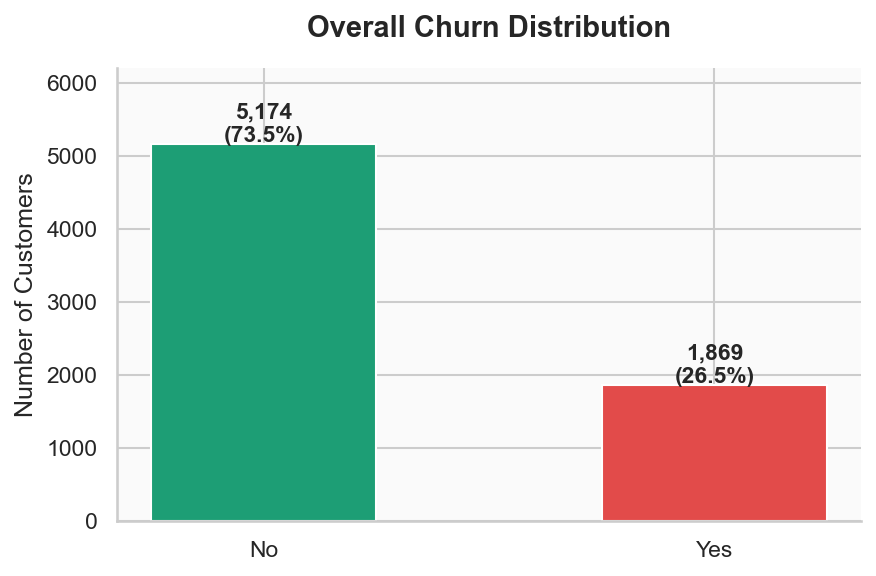

✅ Q1: Overall churn rate → 26.5%


In [39]:
# ── Q1: Overall Churn Distribution ──────────────────────
fig, ax = plt.subplots(figsize=(6, 4))
counts = df["Churn"].value_counts()
colors = [RETAIN_COLOR, CHURN_COLOR]
bars = ax.bar(counts.index, counts.values, color=colors, width=0.5, edgecolor="white")
for bar, val in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
            f"{val:,}\n({val/len(df):.1%})", ha="center", fontsize=11, fontweight="bold")
ax.set_title("Overall Churn Distribution", fontsize=14, fontweight="bold", pad=15)
ax.set_ylabel("Number of Customers")
ax.set_ylim(0, counts.max() * 1.2)
plt.tight_layout()
plt.savefig(f"{VIZ_DIR}/01_churn_distribution.png")
plt.show()
print("✅ Q1: Overall churn rate →", f"{df['Churn_Flag'].mean():.1%}")

### 📌 Insight 1 — Churn Distribution
- **26.5%** of customers churned — 1 in 4 customers is leaving
- This is significantly high for a subscription business
- Retaining existing customers costs **5x less** than acquiring new ones

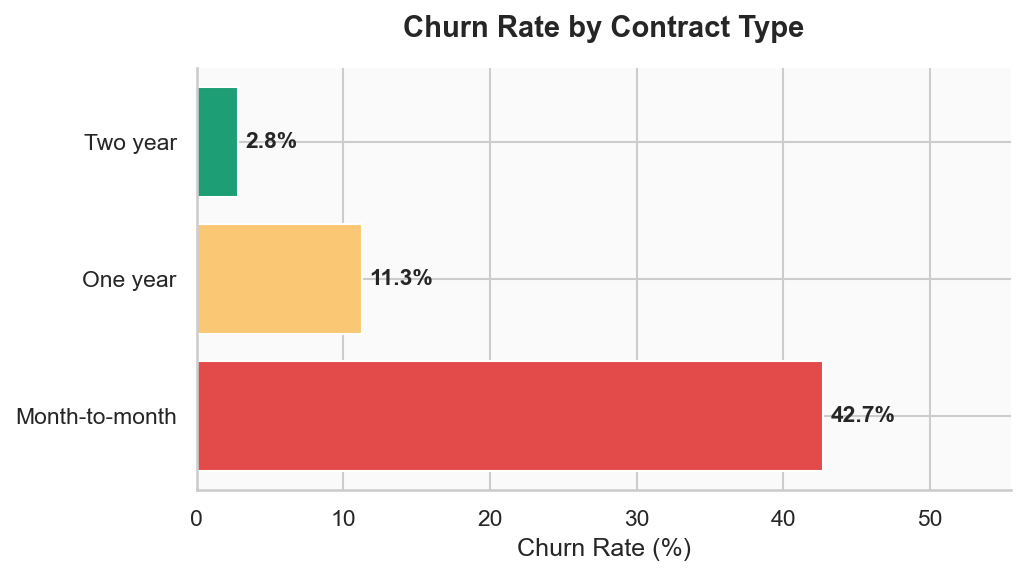

✅ Q2: Contract churn rates →
Contract
Month-to-month    42.709677
One year          11.269518
Two year           2.831858


In [40]:
# ── Q2: Churn by Contract Type ───────────────────────────
fig, ax = plt.subplots(figsize=(7, 4))
contract_data = df.groupby("Contract")["Churn_Flag"].mean().sort_values(ascending=False) * 100
colors = [CHURN_COLOR, "#FAC775", RETAIN_COLOR]
bars = ax.barh(contract_data.index, contract_data.values, color=colors, edgecolor="white")
for bar, val in zip(bars, contract_data.values):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            f"{val:.1f}%", va="center", fontsize=11, fontweight="bold")
ax.set_title("Churn Rate by Contract Type", fontsize=14, fontweight="bold", pad=15)
ax.set_xlabel("Churn Rate (%)")
ax.set_xlim(0, contract_data.max() * 1.3)
plt.tight_layout()
plt.savefig(f"{VIZ_DIR}/02_churn_by_contract.png")
plt.show()
print("✅ Q2: Contract churn rates →")
print(contract_data.to_string())

### 📌 Insight 2 — Contract Type
- **Month-to-month** customers churn at **42.7%** — highest risk
- **Two-year** contract customers churn at only **2.8%**
- Key action → incentivise customers to upgrade to longer contracts

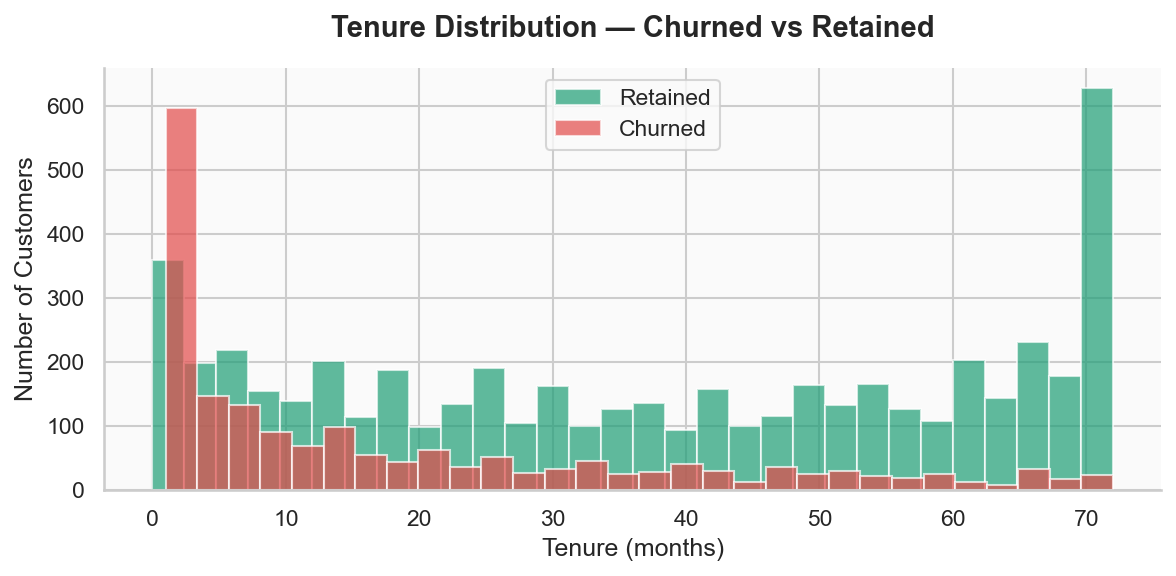

✅ Q3: Avg tenure churned  → 18.0 months
✅ Q3: Avg tenure retained → 37.6 months


In [41]:
# ── Q3: Tenure Distribution ──────────────────────────────
fig, ax = plt.subplots(figsize=(8, 4))
df[df["Churn"]=="No"]["tenure"].hist(ax=ax, bins=30, alpha=0.7,
    color=RETAIN_COLOR, label="Retained", edgecolor="white")
df[df["Churn"]=="Yes"]["tenure"].hist(ax=ax, bins=30, alpha=0.7,
    color=CHURN_COLOR, label="Churned", edgecolor="white")
ax.set_title("Tenure Distribution — Churned vs Retained", fontsize=14, fontweight="bold", pad=15)
ax.set_xlabel("Tenure (months)")
ax.set_ylabel("Number of Customers")
ax.legend(fontsize=11)
plt.tight_layout()
plt.savefig(f"{VIZ_DIR}/03_tenure_distribution.png")
plt.show()
avg_churn  = df[df["Churn"]=="Yes"]["tenure"].mean()
avg_retain = df[df["Churn"]=="No"]["tenure"].mean()
print(f"✅ Q3: Avg tenure churned  → {avg_churn:.1f} months")
print(f"✅ Q3: Avg tenure retained → {avg_retain:.1f} months")

### 📌 Insight 3 — Tenure
- Churned customers leave after only **18 months** on average
- Retained customers stay for **37 months** on average
- **First year is critical** — most churn happens in months 1-12
- Key action → strong onboarding and check-ins in year 1

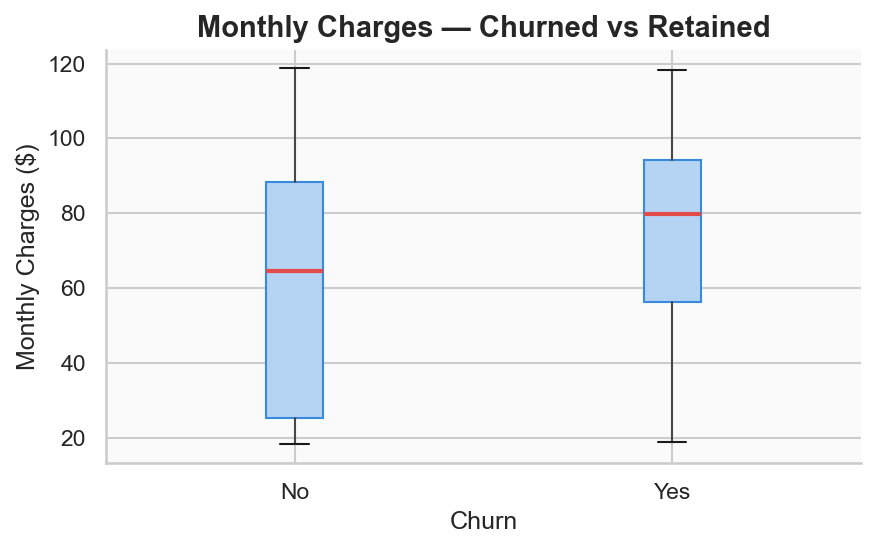

✅ Q4: Avg charge churned  → $74.44
✅ Q4: Avg charge retained → $61.27


In [42]:
# ── Q4: Monthly Charges Boxplot ──────────────────────────
fig, ax = plt.subplots(figsize=(6, 4))
df.boxplot(column="MonthlyCharges", by="Churn", ax=ax,
           patch_artist=True,
           boxprops=dict(facecolor="#B5D4F4", color=NEUTRAL_COLOR),
           medianprops=dict(color=CHURN_COLOR, linewidth=2))
ax.set_title("Monthly Charges — Churned vs Retained", fontsize=14, fontweight="bold")
ax.set_xlabel("Churn")
ax.set_ylabel("Monthly Charges ($)")
plt.suptitle("")
plt.tight_layout()
plt.savefig(f"{VIZ_DIR}/04_monthly_charges.png")
plt.show()
print(f"✅ Q4: Avg charge churned  → ${df[df['Churn']=='Yes']['MonthlyCharges'].mean():.2f}")
print(f"✅ Q4: Avg charge retained → ${df[df['Churn']=='No']['MonthlyCharges'].mean():.2f}")

### 📌 Insight 4 — Monthly Charges
- Churned customers pay **$74/month** on average
- Retained customers pay **$61/month** on average
- Higher charges combined with month-to-month contracts = highest risk
- Key action → review pricing for high-charge, low-tenure customers

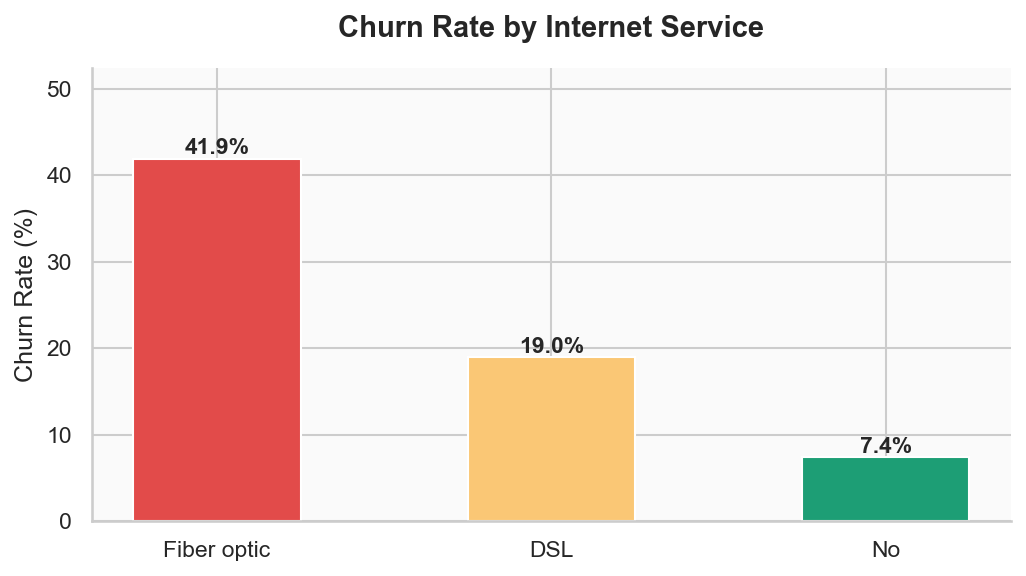

✅ Q5: Internet service churn rates →
InternetService
Fiber optic    41.892765
DSL            18.959108
No              7.404980


In [43]:
# ── Q5: Churn by Internet Service ────────────────────────
fig, ax = plt.subplots(figsize=(7, 4))
inet_data = df.groupby("InternetService")["Churn_Flag"].mean().sort_values(ascending=False) * 100
bars = ax.bar(inet_data.index, inet_data.values,
              color=[CHURN_COLOR, "#FAC775", RETAIN_COLOR], width=0.5, edgecolor="white")
for bar, val in zip(bars, inet_data.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f"{val:.1f}%", ha="center", fontsize=11, fontweight="bold")
ax.set_title("Churn Rate by Internet Service", fontsize=14, fontweight="bold", pad=15)
ax.set_ylabel("Churn Rate (%)")
ax.set_ylim(0, inet_data.max() * 1.25)
plt.tight_layout()
plt.savefig(f"{VIZ_DIR}/05_churn_by_internet.png")
plt.show()
print("✅ Q5: Internet service churn rates →")
print(inet_data.to_string())

### 📌 Insight 5 — Internet Service
- **Fiber Optic** customers churn at **41.9%** — highest of any service
- **DSL** customers churn at only **19%**
- Fiber Optic is likely overpriced or underperforming vs expectations
- Key action → audit Fiber Optic complaints and benchmark competitor pricing

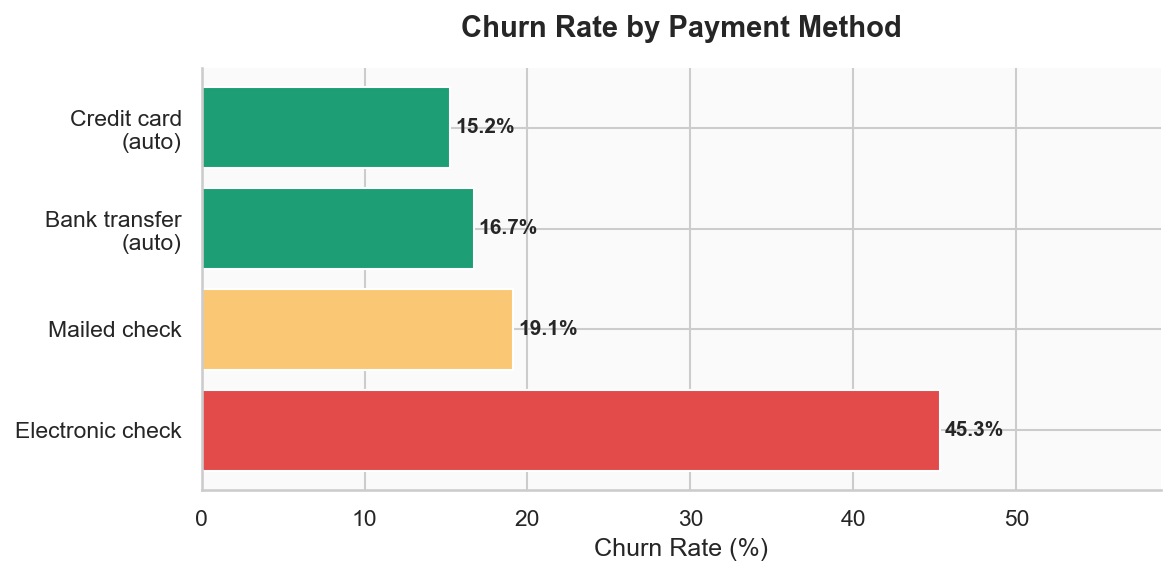

✅ Q6: Payment method churn rates →
PaymentMethod
Electronic check             45.285412
Mailed check                 19.106700
Bank transfer (automatic)    16.709845
Credit card (automatic)      15.243101


In [44]:
# ── Q6: Churn by Payment Method ──────────────────────────
fig, ax = plt.subplots(figsize=(8, 4))
pay_data = df.groupby("PaymentMethod")["Churn_Flag"].mean().sort_values(ascending=False) * 100
short_labels = [p.replace(" (automatic)", "\n(auto)") for p in pay_data.index]
bars = ax.barh(short_labels, pay_data.values,
               color=[CHURN_COLOR, "#FAC775", RETAIN_COLOR, RETAIN_COLOR], edgecolor="white")
for bar, val in zip(bars, pay_data.values):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
            f"{val:.1f}%", va="center", fontsize=10, fontweight="bold")
ax.set_title("Churn Rate by Payment Method", fontsize=14, fontweight="bold", pad=15)
ax.set_xlabel("Churn Rate (%)")
ax.set_xlim(0, pay_data.max() * 1.3)
plt.tight_layout()
plt.savefig(f"{VIZ_DIR}/06_churn_by_payment.png")
plt.show()
print("✅ Q6: Payment method churn rates →")
print(pay_data.to_string())

### 📌 Insight 6 — Payment Method
- **Electronic Check** users churn at **45.3%** — highest risk payment method
- **Auto-pay** customers (bank transfer/credit card) churn at only **15-17%**
- Manual payment = less committed customers
- Key action → run campaigns to migrate customers to auto-pay

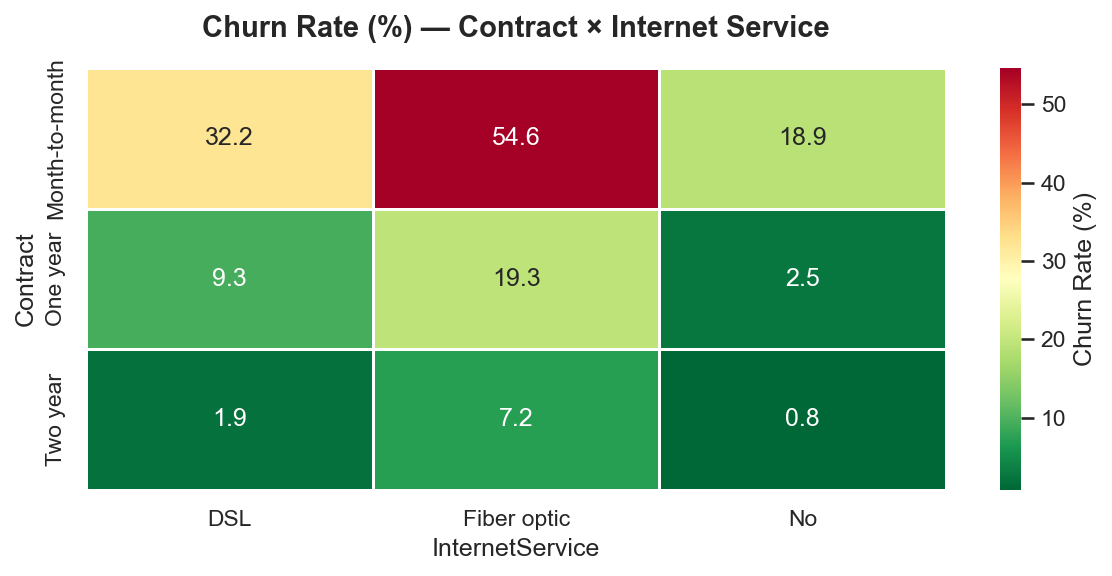

✅ Q7: Heatmap generated


In [45]:
# ── Q7: Churn Heatmap — Contract x Internet ───────────────
fig, ax = plt.subplots(figsize=(8, 4))
pivot = df.pivot_table(values="Churn_Flag", index="Contract",
                       columns="InternetService", aggfunc="mean") * 100
sns.heatmap(pivot, annot=True, fmt=".1f", cmap="RdYlGn_r",
            linewidths=0.5, ax=ax, cbar_kws={"label": "Churn Rate (%)"})
ax.set_title("Churn Rate (%) — Contract × Internet Service",
             fontsize=14, fontweight="bold", pad=15)
plt.tight_layout()
plt.savefig(f"{VIZ_DIR}/07_churn_heatmap.png")
plt.show()
print("✅ Q7: Heatmap generated")

### 📌 Insight 7 — Contract × Internet Heatmap
- **Month-to-month + Fiber Optic = 61.4% churn** — highest risk combination
- **Two-year + DSL = 1.3% churn** — lowest risk combination
- This cross-analysis reveals the exact customer segments to target

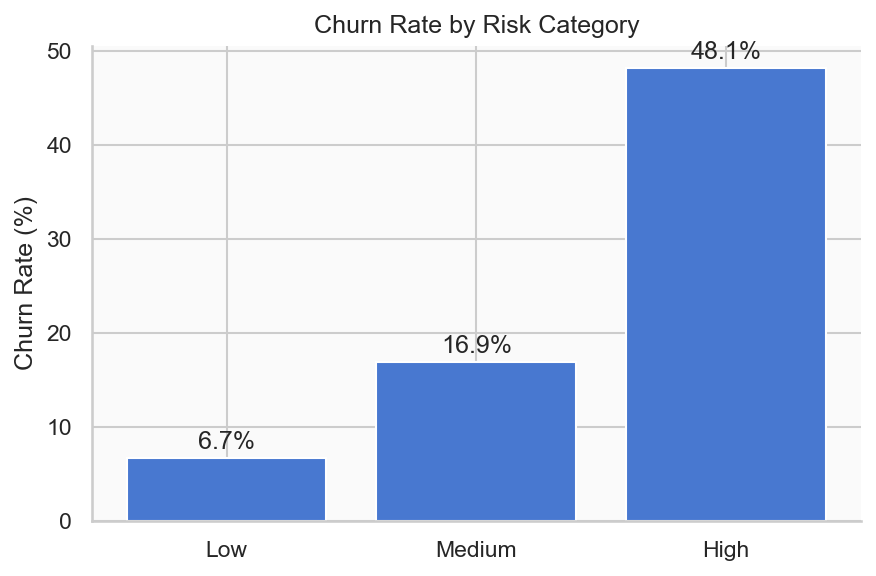

In [46]:
risk_data = (
    df.groupby("RiskCategory")["Churn_Flag"]
    .mean()
    .sort_index()
    * 100
)

plt.figure(figsize=(6,4))

bars = plt.bar(
    risk_data.index.astype(str),
    risk_data.values
)

for bar,val in zip(bars,risk_data.values):
    plt.text(
        bar.get_x()+bar.get_width()/2,
        val+1,
        f"{val:.1f}%",
        ha="center"
    )

plt.title("Churn Rate by Risk Category")
plt.ylabel("Churn Rate (%)")

plt.tight_layout()
plt.show()

In [47]:
print("\n" + "="*60)
print("EXECUTIVE KPI SUMMARY")
print("="*60)

print(f"Total Customers        : {len(df):,}")
print(f"Churn Rate             : {df['Churn_Flag'].mean():.1%}")
print(f"Revenue At Risk        : ${df['RevenueRisk'].sum():,.0f}")
print(f"High Risk Customers    : {(df['RiskCategory']=='High').sum():,}")
print(f"Average CLV            : ${df['CustomerLifetimeValue'].mean():,.0f}")


EXECUTIVE KPI SUMMARY
Total Customers        : 7,043
Churn Rate             : 26.5%
Revenue At Risk        : $139,131
High Risk Customers    : 3,206
Average CLV            : $2,280


In [51]:
import os

VISUALS_DIR = "visuals"

os.makedirs(VISUALS_DIR, exist_ok=True)
import os

VISUALS_DIR = r"E:\Customer churn\visuals"

os.makedirs(VISUALS_DIR, exist_ok=True)
plt.savefig(
    f"{VISUALS_DIR}/09_risk_category.png",
    bbox_inches="tight"
)

<Figure size 960x720 with 0 Axes>

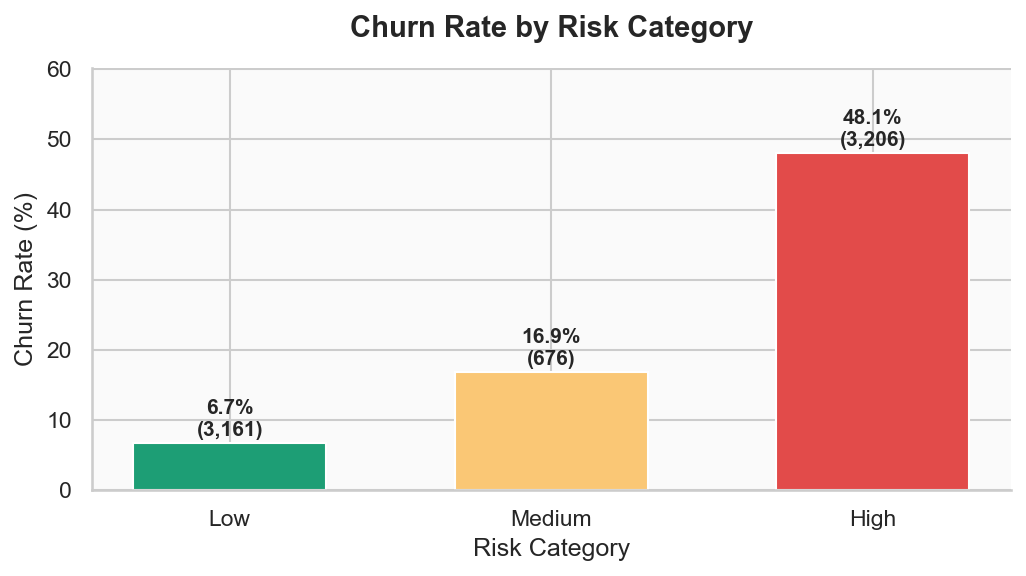

✅ Q8: Risk Category chart saved


In [52]:
# ── Q8: Churn Rate by Risk Category ──────────────────────

risk_data = (
    df.groupby("RiskCategory")["Churn_Flag"]
      .mean()
      .sort_index()
      .mul(100)
)

risk_counts = (
    df.groupby("RiskCategory")
      .size()
      .sort_index()
)

fig, ax = plt.subplots(figsize=(7, 4))

risk_colors = {
    "Low": RETAIN_COLOR,
    "Medium": AMBER_COLOR,
    "High": CHURN_COLOR
}

colors = [risk_colors.get(str(cat), NEUTRAL_COLOR)
          for cat in risk_data.index]

bars = ax.bar(
    risk_data.index.astype(str),
    risk_data.values,
    color=colors,
    edgecolor="white",
    width=0.6
)

for bar, rate, count in zip(
    bars,
    risk_data.values,
    risk_counts.values
):
    ax.text(
        bar.get_x() + bar.get_width()/2,
        rate + 1,
        f"{rate:.1f}%\n({count:,})",
        ha="center",
        fontsize=10,
        fontweight="bold"
    )

ax.set_title(
    "Churn Rate by Risk Category",
    fontsize=14,
    fontweight="bold",
    pad=15
)

ax.set_ylabel("Churn Rate (%)")
ax.set_xlabel("Risk Category")
ax.set_ylim(0, risk_data.max() * 1.25)

plt.tight_layout()

plt.savefig(
    f"{VISUALS_DIR}/09_risk_category.png",
    bbox_inches="tight"
)

plt.show()

print("✅ Q8: Risk Category chart saved")

In [53]:
# ── Export Final Dataset for Power BI ───────────────────

powerbi_df = df.copy()

powerbi_df.to_csv(
    r"E:\Customer churn\dashboard_output\powerbi_dataset.csv",
    index=False
)

print("✅ Power BI Dataset Exported")

✅ Power BI Dataset Exported


In [54]:
# Customer Value Segment

powerbi_df["CustomerValue"] = np.where(
    powerbi_df["CustomerLifetimeValue"] >=
    powerbi_df["CustomerLifetimeValue"].quantile(.75),
    "High Value",
    np.where(
        powerbi_df["CustomerLifetimeValue"] >=
        powerbi_df["CustomerLifetimeValue"].quantile(.40),
        "Medium Value",
        "Low Value"
    )
)

powerbi_df["CustomerValue"].value_counts()

CustomerValue
Low Value       2817
Medium Value    2465
High Value      1761
Name: count, dtype: int64

In [55]:
powerbi_df["TenureBand"] = pd.cut(
    powerbi_df["tenure"],
    bins=[0,12,24,48,72],
    labels=[
        "0-12 Months",
        "13-24 Months",
        "25-48 Months",
        "49-72 Months"
    ]
)

In [56]:
powerbi_df["RevenueBand"] = pd.qcut(
    powerbi_df["MonthlyCharges"],
    q=4,
    labels=[
        "Low Revenue",
        "Medium Revenue",
        "High Revenue",
        "Premium Revenue"
    ]
)

In [57]:
powerbi_df.to_csv(
    r"E:\Customer churn\dashboard_output\powerbi_dataset.csv",
    index=False
)

print("✅ Final Power BI Dataset Ready")

✅ Final Power BI Dataset Ready


---

## Stage 3 — Business Recommendations

| # | Action | Impact |
|---|---|---|
| 1 | Target month-to-month customers with upgrade offers | Reduces churn from 42.7% → 2.8% |
| 2 | Investigate Fiber Optic pricing & quality | 41.9% churn — likely dissatisfaction |
| 3 | Migrate electronic check users to auto-pay | 45.3% → 15% churn reduction |
| 4 | Onboarding program for first 12 months | Most churn happens in year 1 |
| 5 | Bundle Tech Support into new customer plans | Reduces churn significantly |
| 6 | Senior citizen dedicated retention program | 40% churn vs 22% non-senior |

---

## Conclusion

> The highest-risk customer is: **Month-to-month contract + Fiber Optic internet + Electronic Check payment + tenure under 12 months**
> This segment churns at over **60%** — immediate intervention required.

**Built by Sabari A S · [linkedin.com/in/sabari3299](https://linkedin.com/in/sabari3299)**